# Login the AWS related configuration

In [4]:
import os

aws_access_key_id = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY")

os.environ['AWS_ACCESS_KEY_ID'] = aws_access_key_id
os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_access_key
os.environ['AWS_REGION'] = 'ap-northeast-2'

# Import Sagemaker Runtime

In [6]:
import boto3

boto_session = boto3.Session(
    aws_access_key_id = aws_access_key_id,
    aws_secret_access_key = aws_secret_access_key,
    region_name = os.environ['AWS_REGION']
)

sm_runtime = boto_session.client("sagemaker-runtime")

In [20]:
# change your endpoint name
zero_endpoint_name = "zero-marketplace"

# Simple Visualizer

In [16]:
import json
import requests
import base64
from io import BytesIO
from typing import Union

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


def visualize_detection(
    detection_result: dict,
    img: Image.Image,
    color: str = "red",
    font_color: str = "black",
) -> None:
    """
    Visualizes object detection results on an image.

    Args:
        detection_result (dict): The detection result data.
                                 Expected format: {'output': [{'boxes': [[x1, y1, x2, y2], ...], 'text': ['label1', ...]}]}
        img (Image.Image): The PIL Image object to draw on.
        color (str, optional): The color for the bounding box and label background. Defaults to "red".
        font_color (str, optional): The color for the label text. Defaults to "black".
    """
    draw = ImageDraw.Draw(img)

    # Extract data from the detection result
    # Assumes the detection_result structure is fixed.
    try:
        detections = detection_result["output"][0]
        boxes = detections["boxes"]
        labels = detections["text"]
    except (KeyError, IndexError) as e:
        print(f"Error: Unexpected detection_result structure. {e}")
        return

    # Draw bounding boxes and labels on the image.
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box

        # Draw bounding box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)

        # Draw text label background
        # Width adjustment might be needed depending on the font or text length.
        text_bbox = draw.textbbox((x1, y1), label)
        text_width = text_bbox[2] - text_bbox[0]
        text_height = text_bbox[3] - text_bbox[1]
        
        draw.rectangle(
            [x1, y1 - text_height - 5, x1 + text_width + 10, y1], fill=color
        )

        # Draw text label
        draw.text((x1 + 5, y1 - text_height - 5), label, fill=font_color)

    # Display the result image
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


def base64_decode(
    raw_data: Union[str, bytes], urlsafe: bool = False, pad: bool = True
) -> str:
    """
    Decodes a base64 encoded string or bytes.

    Args:
        raw_data (Union[str, bytes]): The base64 data to decode.
        urlsafe (bool, optional): Whether to use the URL-safe base64 alphabet. Defaults to False.
        pad (bool, optional): Whether to add padding ('==') automatically. Defaults to True.

    Returns:
        str: The decoded UTF-8 string.
    """
    if isinstance(raw_data, str):
        data = raw_data.encode("utf-8")
    else:
        data = raw_data

    if pad:
        missing_padding = len(data) % 4
        if missing_padding:
            data += b"=" * (4 - missing_padding)

    decoder = base64.urlsafe_b64decode if urlsafe else base64.b64decode
    return decoder(data).decode("utf-8")

def base64_encode(
    data: Union[str, bytes], urlsafe: bool = False, strip_pad: bool = False
) -> str:
    """
    Encodes a string or bytes to base64.

    Args:
        data (Union[str, bytes]): The data to encode.
        urlsafe (bool, optional): Whether to use the URL-safe base64 alphabet. Defaults to False.
        strip_pad (bool, optional): Whether to strip padding ('==') from the output. Defaults to False.

    Returns:
        str: The base64 encoded string.
    """
    if isinstance(data, str):
        data = data.encode("utf-8")  # Convert to bytes

    encoder = base64.urlsafe_b64encode if urlsafe else base64.b64encode
    encoded = encoder(data).decode("utf-8")

    if strip_pad:
        encoded = encoded.rstrip("=")

    return encoded

# Text based inference
We will find `strawberry` in the following image

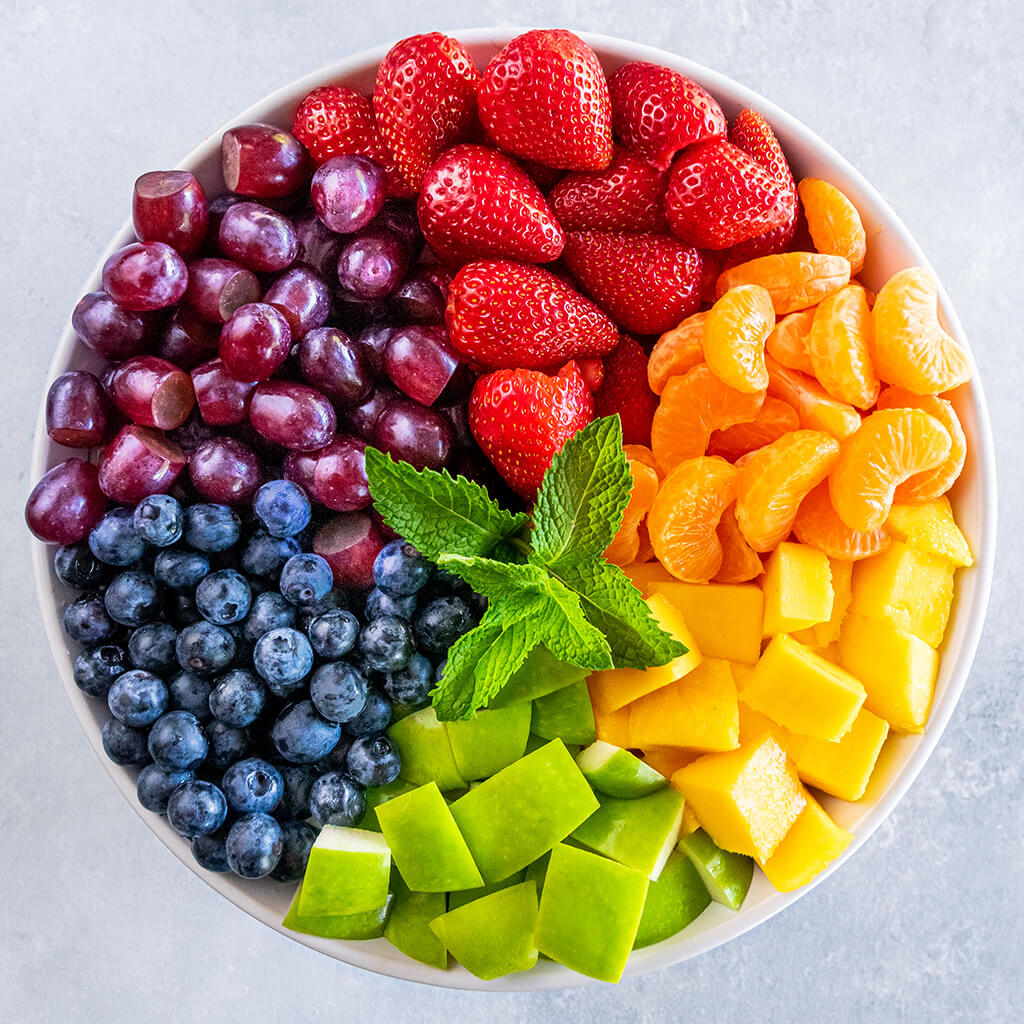

In [58]:
image_url = "https://www.californiastrawberries.com/wp-content/uploads/2021/05/Rainbow-Fruit-Salad-1024.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")
image

In [59]:
seaarch_image_buffered = BytesIO()
image.save(seaarch_image_buffered, format="JPEG")
search_image_base64 = base64_encode(seaarch_image_buffered.getvalue())

body = {
    "search_image": f"data:image/jpeg;base64,{search_image_base64}",
    "queries": [
        {
            "prompt_image": "", 
            "prompts": [
                {
                    "text": "strawberry",
                    "box": [],
                    "box_threshold": 0.1,
                    "multimodal_threshold": 0.22
                }
            ]
        }
    ]
}

response = sm_runtime.invoke_endpoint(
    EndpointName=zero_endpoint_name,
    Body=json.dumps(body),
    ContentType="application/json",
)

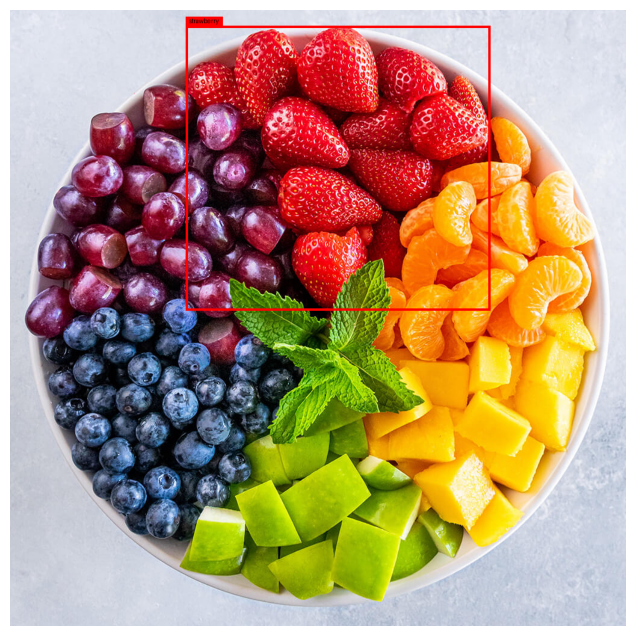

In [60]:
detection_result = json.load(response["Body"])
visualize_detection(detection_result, image)

# Semantic based inference
We will find `potato` in the following image. Note that box is only used for inference.

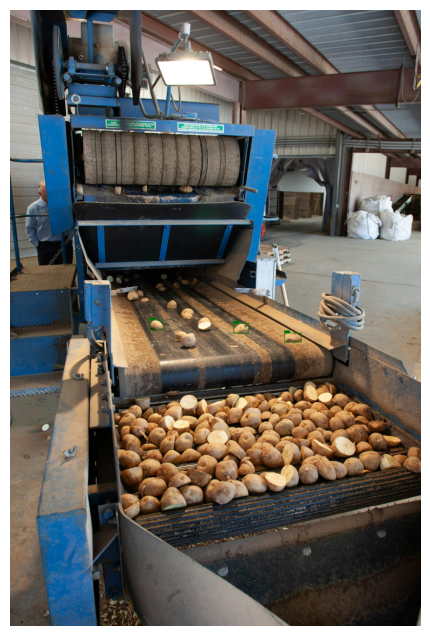

In [61]:
image_url = "https://images.pexels.com/photos/2889199/pexels-photo-2889199.jpeg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")
ground_truth = {'output': 
    [
        {
            'boxes': [
                [1779.5828857421875, 2096.025634765625, 1891.6937255859375, 2158.37548828125], 
                [1450.27734375, 2034.58447265625, 1549.1326904296875, 2100.104736328125], 
                [907.7588500976562, 2012.329833984375, 994.8242797851562, 2078.3623046875]
            ], 
            'text': ['potato', 'potato', 'potato', 'potato']
        }
    ]
}
visualize_detection(ground_truth, image, color="green") # Visualize bounding box with ground_truth

In [62]:
seaarch_image_buffered = BytesIO()
image.save(seaarch_image_buffered, format="JPEG")
search_image_base64 = base64_encode(seaarch_image_buffered.getvalue())

body = {
    "search_image":  f"data:image/jpeg;base64, {search_image_base64}",
    "queries": [
        {
            "prompt_image":  f"data:image/jpeg;base64, {search_image_base64}",
            "prompts": [
                {
                    "text": "potato",
                    "box": [1779.5828857421875, 2096.025634765625, 1891.6937255859375, 2158.37548828125],
                    "box_threshold": 0.1,
                    "multimodal_threshold": 0.3
                },
                {
                    "text": "potato",
                    "box": [1450.27734375, 2034.58447265625, 1549.1326904296875, 2100.104736328125],
                    "box_threshold": 0.1,
                    "multimodal_threshold": 0.3
                },
                {
                    "text": "potato",
                    "box": [907.7588500976562, 2012.329833984375, 994.8242797851562, 2078.3623046875],
                    "box_threshold": 0.1,
                    "multimodal_threshold": 0.3
                }
            ]
        }
    ]
}

response = sm_runtime.invoke_endpoint(
    EndpointName=zero_endpoint_name,
    Body=json.dumps(body),
    ContentType="application/json",
)

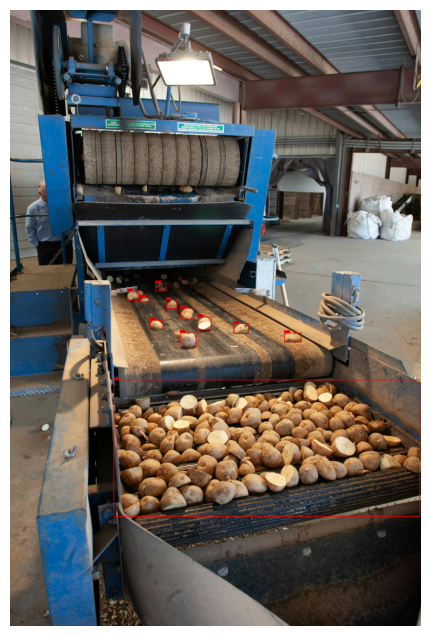

In [63]:
detection_result = json.load(response["Body"])
visualize_detection(detection_result, image)

# Semantic based inference (Advanced)
We will find `elephant` and `giraffe` in the following image. Note that semantic prompts can be extracted from other images.

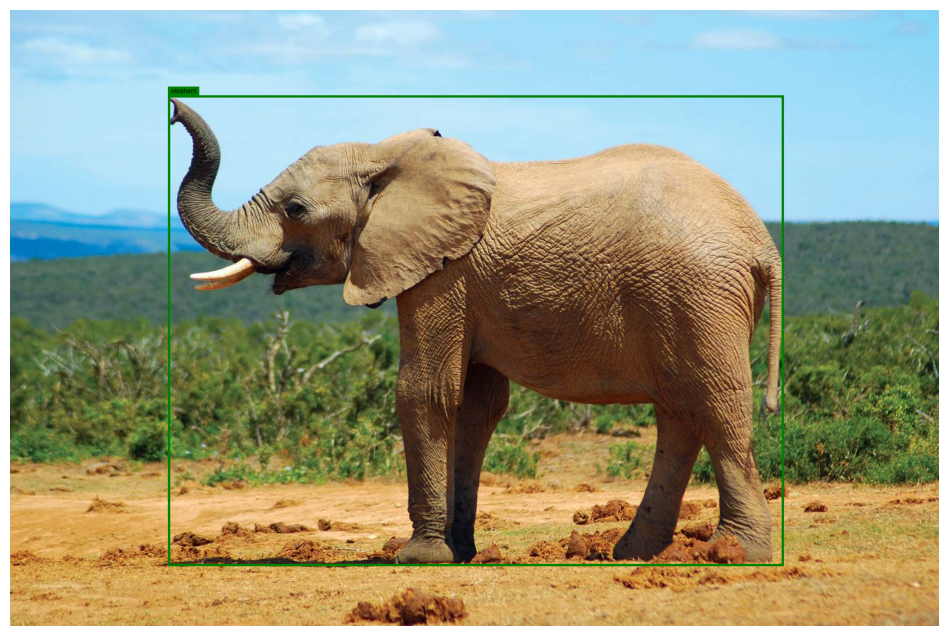

In [64]:
image_url = "https://cdn.britannica.com/02/152302-050-1A984FCB/African-savanna-elephant.jpg"
response = requests.get(image_url)
elephant_image = Image.open(BytesIO(response.content)).convert("RGB")
ground_truth = {'output': 
    [
        {
            'boxes': [
                [272.6648254394531, 147.77137756347656, 1332.71044921875, 958.507568359375]
            ], 
            'text': ['elephant']
        }
    ]
}
visualize_detection(ground_truth, elephant_image, color="green") # Visualize bounding box with ground_truth

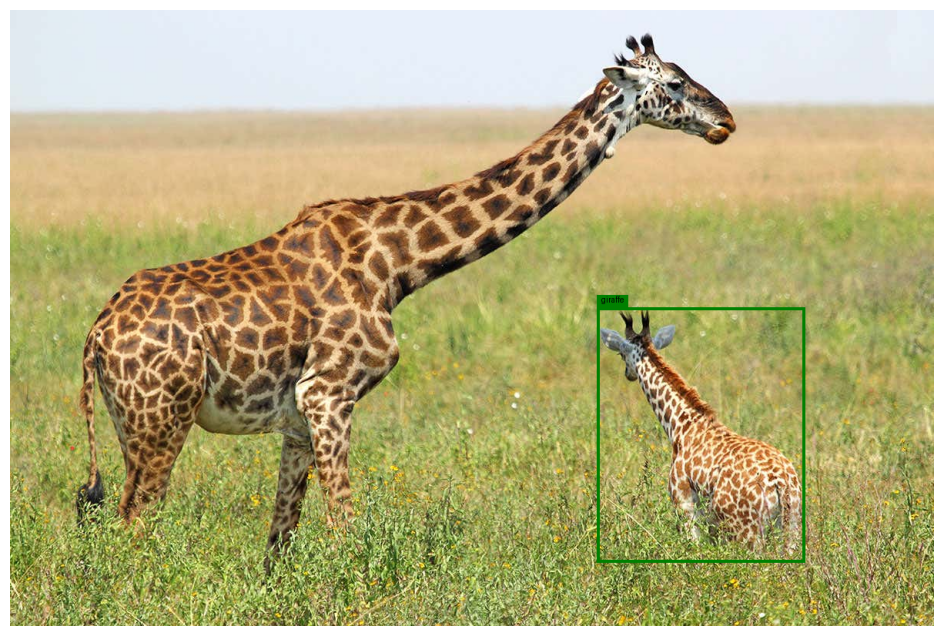

In [65]:
image_url = "https://images.newscientist.com/wp-content/uploads/2018/10/30192224/da7bdk.jpg"
response = requests.get(image_url)
giraffe_image = Image.open(BytesIO(response.content)).convert("RGB")
ground_truth = {'output': 
    [
        {
            'boxes': [
                [762.9100341796875, 386.1495361328125, 1032.3199462890625, 717.8472900390625]
            ], 
            'text': ['giraffe']
        }
    ]
}
visualize_detection(ground_truth, giraffe_image, color="green") # Visualize bounding box with ground_truth

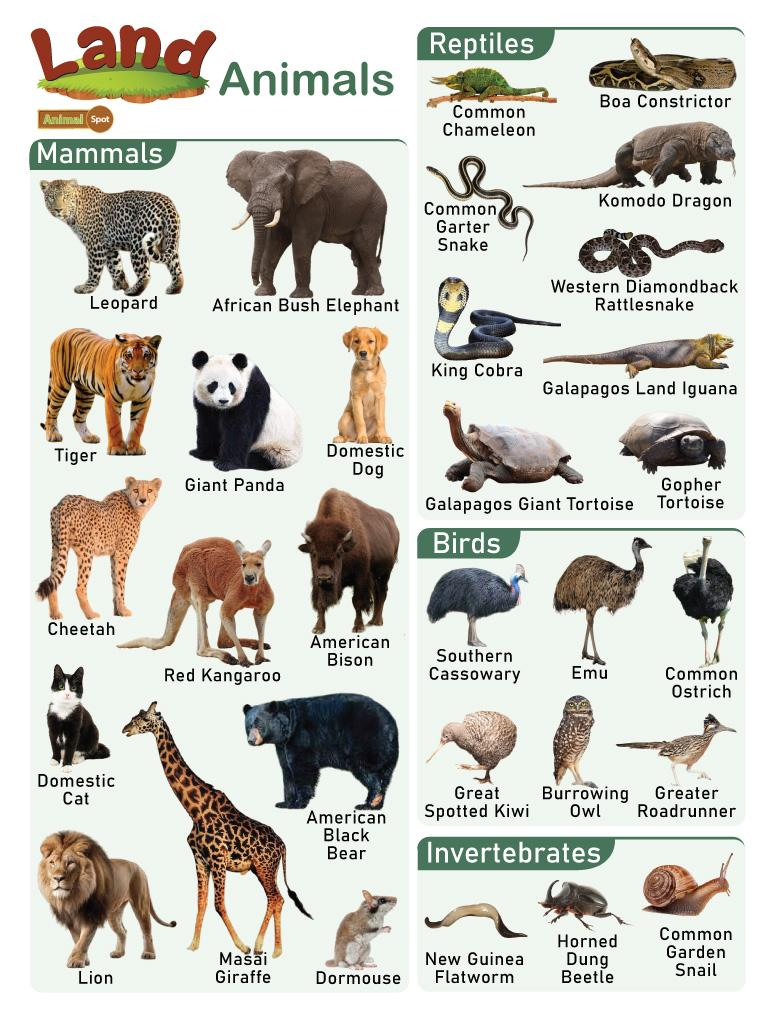

In [66]:
image_url = "https://www.animalspot.net/wp-content/uploads/2023/07/Land-Animals.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")
image

In [67]:
seaarch_image_buffered = BytesIO()
image.save(seaarch_image_buffered, format="JPEG")
search_image_base64 = base64_encode(seaarch_image_buffered.getvalue())

elephant_image_buffered = BytesIO()
elephant_image.save(elephant_image_buffered, format="JPEG")
elephant_image_base64 = base64_encode(elephant_image_buffered.getvalue())

giraffe_image_buffered = BytesIO()
giraffe_image.save(giraffe_image_buffered, format="JPEG")
giraffe_image_base64 = base64_encode(giraffe_image_buffered.getvalue())

body = {
    "search_image": f"data:image/jpeg;base64, {search_image_base64}",
    "queries": [
        {
            "prompt_image": f"data:image/jpeg;base64, {elephant_image_base64}", 
            "prompts": [
                {"text": "elephant",
                 "box": [272.6648254394531, 147.77137756347656, 1332.71044921875, 958.507568359375],
                 "box_threshold": 0.1,
                 "multimodal_threshold": 0.15
                }
            ]
        },
        {
            "prompt_image": f"data:image/jpeg;base64, {giraffe_image_base64}", 
            "prompts": [
                {
                    "text": "giraffe",
                    "box": [762.9100341796875, 386.1495361328125, 1032.3199462890625, 717.8472900390625],
                    "box_threshold": 0.1,
                    "multimodal_threshold": 0.2
                }
            ]
        }
    ]
}

response = sm_runtime.invoke_endpoint(
    EndpointName=zero_endpoint_name,
    Body=json.dumps(body),
    ContentType="application/json",
)

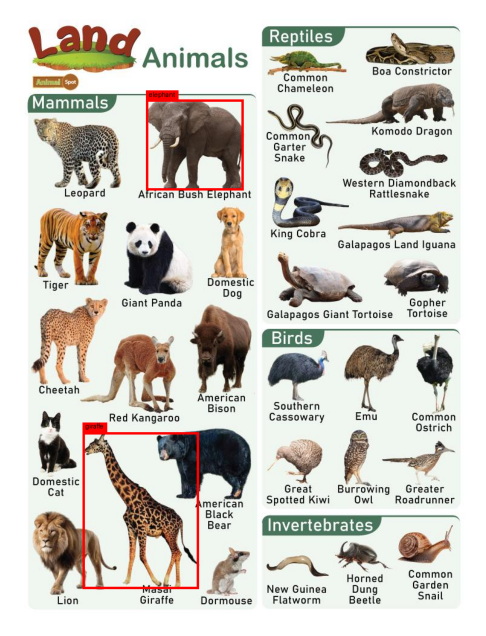

In [68]:
detection_result = json.load(response["Body"])
visualize_detection(detection_result, image)